# **Modelo GARCH**

In [ ]:
# Instalamos las librería arch que no se encuentra preinstalada en Google Colab
!pip install arch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 18.9 MB/s eta 0:00:00


In [ ]:
# IMPORTAMOS LAS LIBRERÍAS NECESARIAS
# Procesamiento de datos
import yfinance as yf
import math
import numpy as np
import pandas as pd
# Modelos ARCH
from arch import arch_model
from arch.__future__ import reindexing
# Representación de datos
import matplotlib.pyplot as plt
from tabulate import tabulate
# Medidas del error
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

/usr/local/lib/python3.10/dist-packages/yfinance/base.py:48: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  _empty_series = pd.Series()


In [ ]:
empresas = [
    'TSLA', #Tesla
    'GOOG', #Google
    'META', #Meta
    'AMZN', #Amazon
    'MSFT', #Microsoft
    'AAPL', #Apple
]
# Indicar el tipo de volatilidad a predecir en td como:
# 'D' --> Dayly (Diaria) 'W' --> Weekly (Semanal) 'M' --> Monthly (Mensual)
td = 'D'
if (td == 'D'):
  dtime = 'diaria'
  test_size = 150
elif (td == 'W'):
   dtime = 'semanal'
   test_size = 100
else:
  dtime = 'mensual'
  test_size = 50
# Indicar el tamaño de la ventana
N = 5

[*********************100%%**********************]  1 of 1 completed


Mejor orden (p, q) según AIC para TSLA: (2, 4)


[*********************100%%**********************]  1 of 1 completed

(148,)
╒══════╤════════╤════════╤════════╕
│      │  MSE   │  RMSE  │  MAPE  │
╞══════╪════════╪════════╪════════╡
│ TSLA │ 4.9682 │ 2.2289 │ 0.5619 │
╘══════╧════════╧════════╧════════╛


Mejor orden (p, q) según AIC para GOOG: (1, 2)


...

(148,)
╒══════╤════════╤════════╤════════╕
│      │  MSE   │  RMSE  │  MAPE  │
╞══════╪════════╪════════╪════════╡
│ AMZN │ 1.9052 │ 1.3803 │ 0.5403 │
╘══════╧════════╧════════╧════════╛


Mejor orden (p, q) según AIC para MSFT: (1, 1)


[*********************100%%**********************]  1 of 1 completed

(148,)
╒══════╤════════╤════════╤════════╕
│      │  MSE   │  RMSE  │  MAPE  │
╞══════╪════════╪════════╪════════╡
│ MSFT │ 1.1649 │ 1.0793 │ 0.5359 │
╘══════╧════════╧════════╧════════╛


Mejor orden (p, q) según AIC para AAPL: (1, 1)
(148,)
╒══════╤════════╤════════╤════════╕
│      │  MSE   │  RMSE  │  MAPE  │
╞══════╪════════╪════════╪════════╡
│ AAPL │ 0.8110 │ 0.9006 │ 0.5112 │
╘══════╧════════╧════════╧════════╛


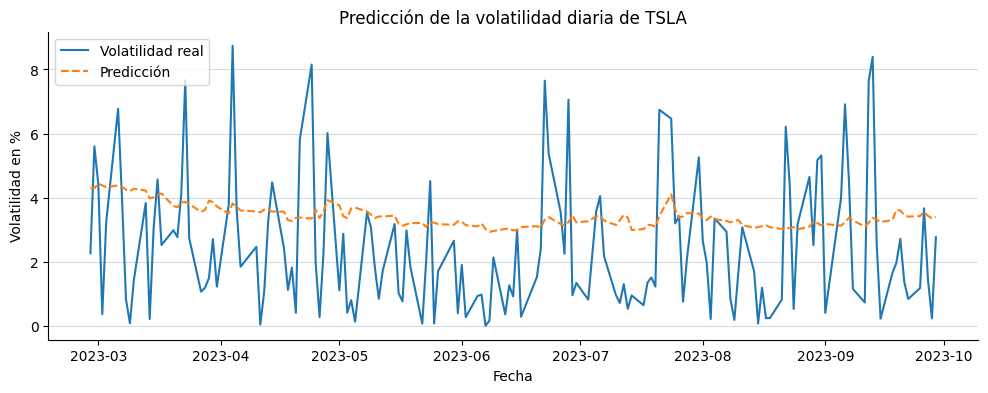

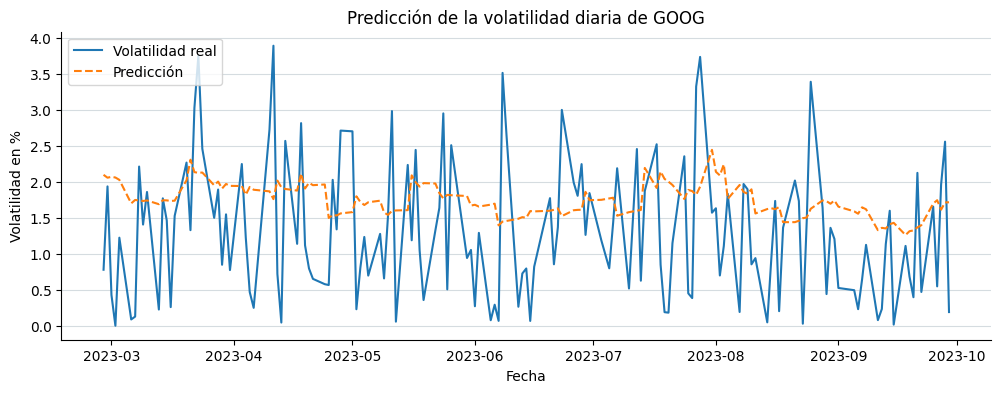

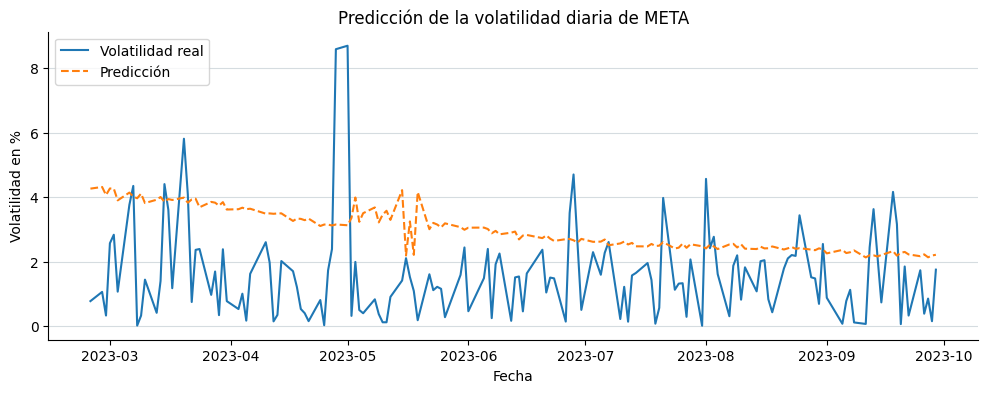

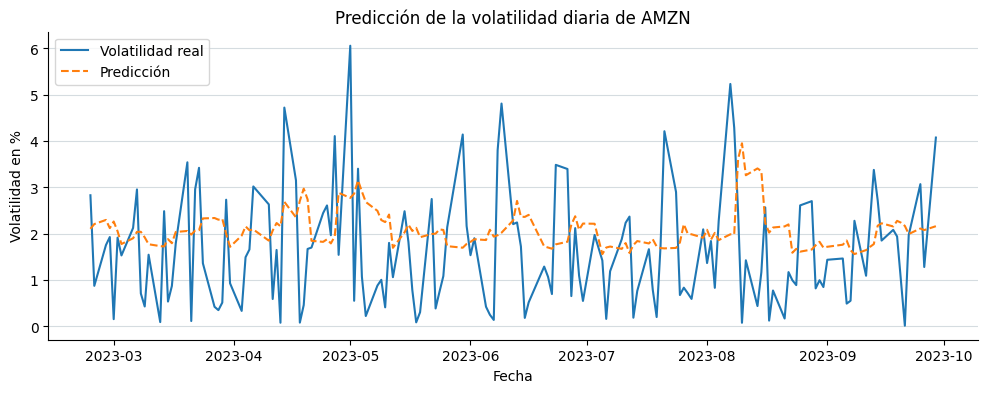

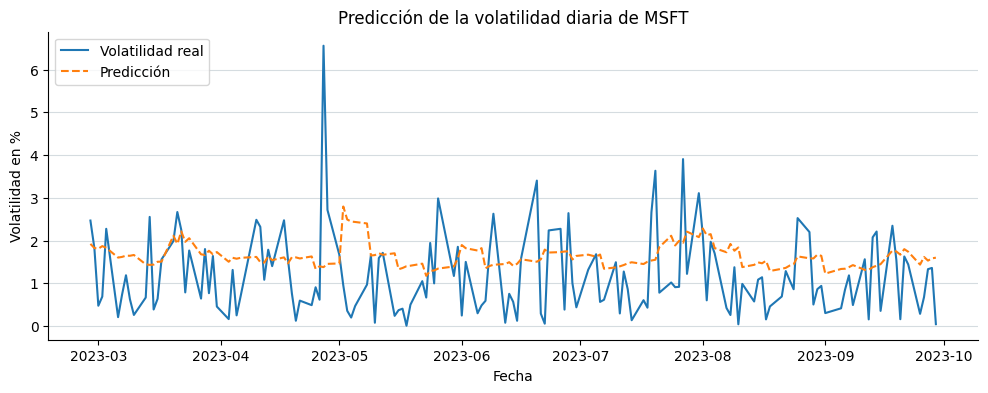

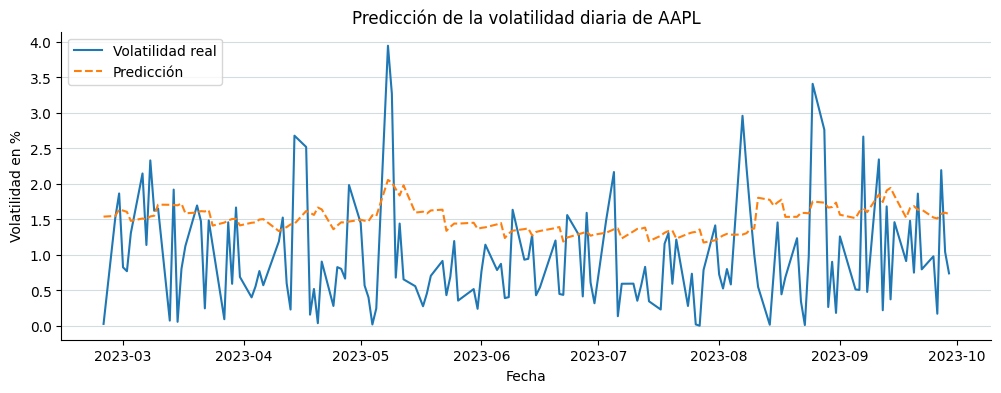

In [ ]:
rent = pd.DataFrame()
for emp in empresas:
  ticker = emp
  data = yf.download(ticker, start="2012-05-18", end="2023-09-30")
  data['R_Log'] = 100*data['Close'].apply(np.log).diff().dropna()
  rent= data['R_Log'].resample(td).sum()
  rentabilidad = rent.replace(0.000000, np.nan).dropna()
  vol = rentabilidad.rolling(window=2).std().dropna()
  best_aic = np.inf
  # BUCLE DE ESTIMACIÓN DE LOS PARÁMETROS P Y Q
  P, Q = [1,2,3,4], [1,2,3,4]
  for p in P:  # Rango de valores para el componente autoregresivo (p)
    for q in Q:  # Rango de valores para el componente de media móvil (q)
           model = arch_model(rentabilidad, vol='GARCH', p=p, q=q)
           results = model.fit(disp='off')
           aic = results.aic
           if aic < best_aic:
              best_aic = aic
              best_order = (p, q)
  print(f'Mejor orden (p, q) según AIC para {emp}:', best_order)

  # BUCLE DE PREDICCIÓN
  rolling_predictions = []
  # Bucle de predicción
  for i in range(0,test_size,N):
      train = rentabilidad[i:-(test_size-i)] # Datos de entrenamiento usando ventana móvil ¿Rentabilidad o Volatilidad como entrada?
      # Definimos y entrenamos el modelo
      model = arch_model(train, p=p, q=q, mean = 'constant', vol = 'GARCH', dist = 'normal')
      model_fit = model.fit(disp='off')
      # Predecimos los N siguientes valores
      pred = model_fit.forecast(horizon=N)
      # Calculamos la volatilidad aplicando sqrt a la media de la varianza de los valores predecidos
      rolling_predictions.extend(np.sqrt(pred.variance.values[-1,:]))
  # Transformamos el vector de la volatilidad predicha en una serie con el mismo indice que los retornos diarios
  rolling_predictions = pd.Series(rolling_predictions, index=vol.index[-test_size:])
  rolling_predictions = rolling_predictions.dropna() # Nos aseguramos que los índices coincidan
  print(rolling_predictions[2:].shape)
  # CALCULO RMSE y MAPE
  vol_moved = vol[-test_size-1:].shift(1).dropna() # N=1 --> 2
  mse = mean_squared_error(rolling_predictions, vol_moved)
  rmse = np.sqrt(mse)
  mape = mean_absolute_percentage_error(rolling_predictions, vol_moved)
  print(tabulate([[ticker,mse,rmse,mape]],
                headers = ['MSE', 'RMSE', 'MAPE'],
                tablefmt = 'fancy_grid',stralign='center',numalign='center',floatfmt=".4f"))
  # GRÁFICO PRED vs REAL
  fig,ax = plt.subplots(figsize=(12,4))
  ax.grid(which="major", axis='y', color='#758D99', alpha=0.3, zorder=1)
  ax.spines[['top', 'right']].set_visible(False)
  plt.plot(vol_moved.index, vol_moved, label='Volatilidad Real')
  plt.plot(rolling_predictions, linestyle='--')
  plt.title(f'Predicción de la volatilidad {dtime} de {ticker}')
  plt.legend(['Volatilidad real','Predicción',], loc='upper left')
  plt.xlabel('Fecha')
  plt.ylabel('Volatilidad en %')

# **Modelo EGARCH**

[*********************100%%**********************]  1 of 1 completed
Mejor orden (p, q) según AIC para TSLA: (3, 2)
(98,)
╒══════╤═════════╤════════╤════════╕
│      │   MSE   │  RMSE  │  MAPE  │
╞══════╪═════════╪════════╪════════╡
│ TSLA │ 25.7921 │ 5.0786 │ 0.4863 │
╘══════╧═════════╧════════╧════════╛
[*********************100%%**********************]  1 of 1 completed
Mejor orden (p, q) según AIC para GOOG: (1, 2)
(98,)
╒══════╤════════╤════════╤════════╕
│      │  MSE   │  RMSE  │  MAPE  │
╞══════╪════════╪════════╪════════╡
│ GOOG │ 8.8798 │ 2.9799 │ 0.5731 │
╘══════╧════════╧════════╧════════╛
[*********************100%%**********************]  1 of 1 completed
Mejor orden (p, q) según AIC para META: (2, 2)
(98,)
╒══════╤═════════╤════════╤════════╕
│      │   MSE   │  RMSE  │  MAPE  │
╞══════╪═════════╪════════╪════════╡
│ META │ 21.9433 │ 4.6844 │ 0.6110 │
╘══════╧═════════╧════════╧════════╛
[*********************100%%**********************]  1 of 1 completed
Mejor orden (p,

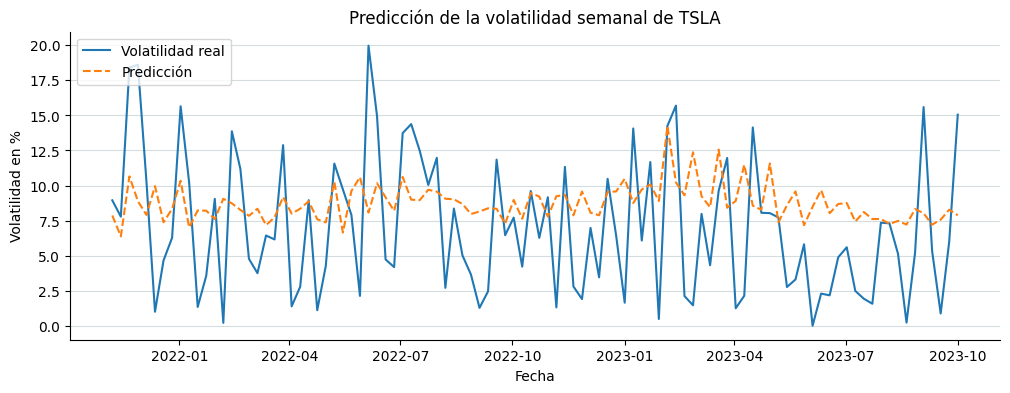

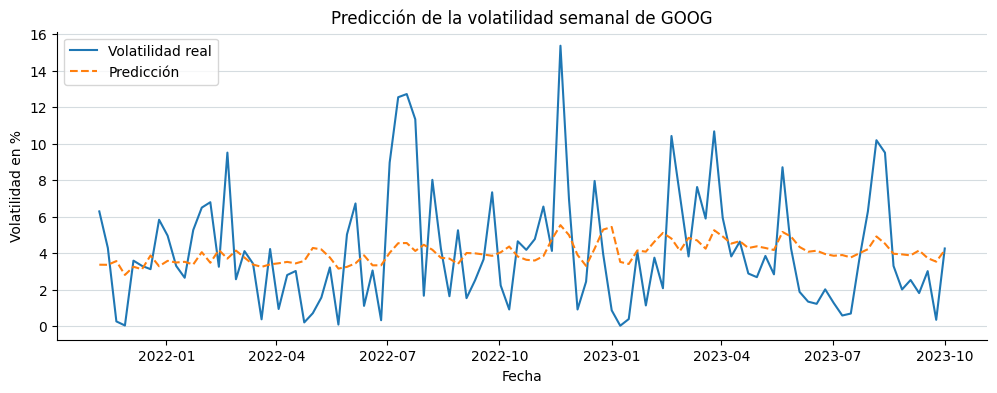

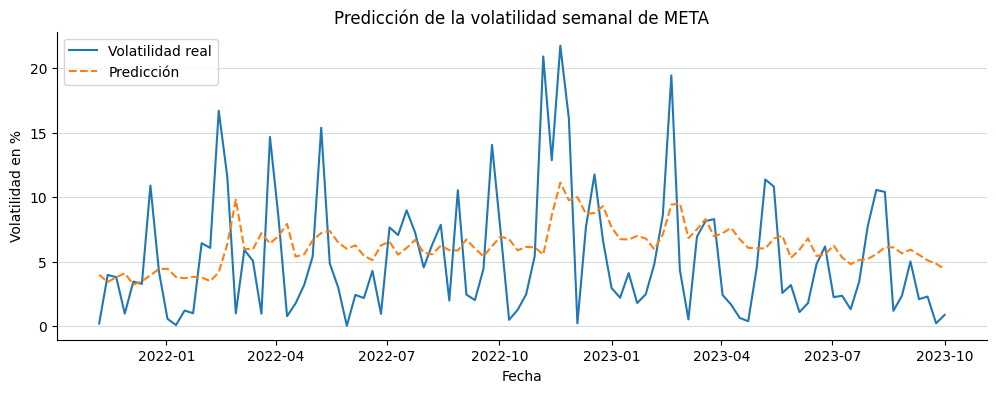

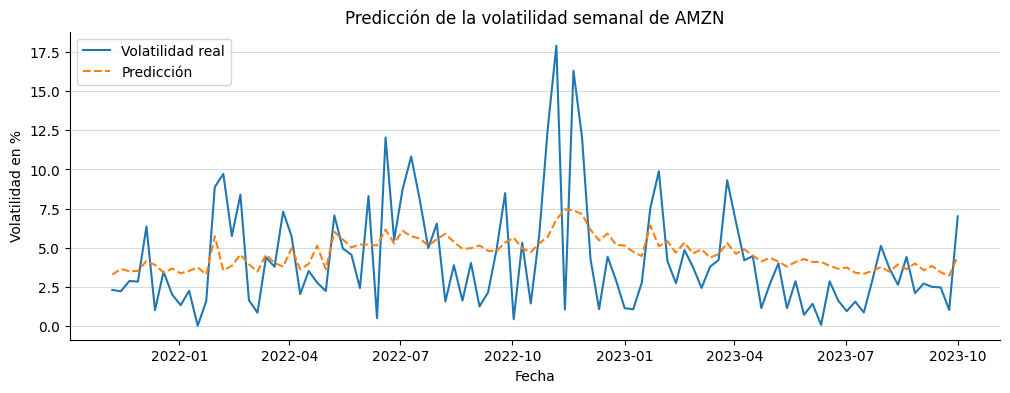

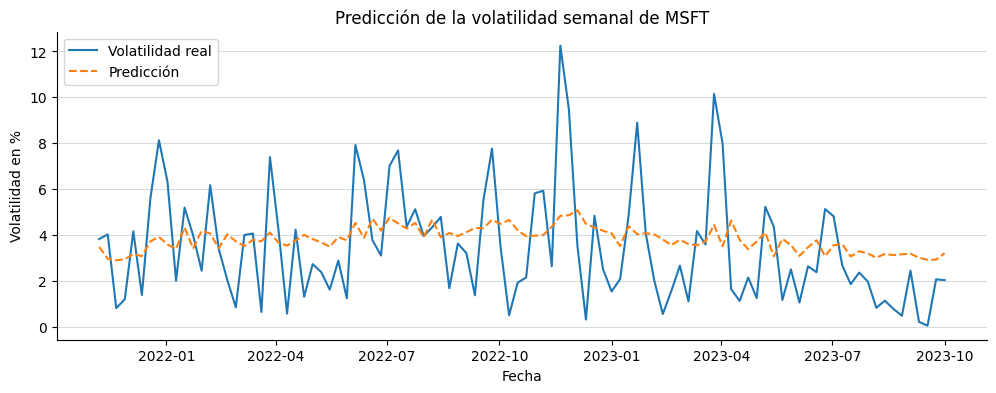

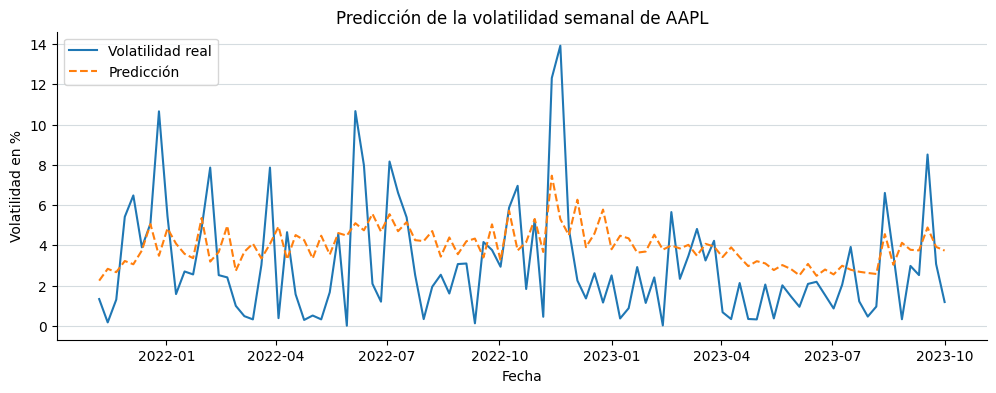

In [ ]:
rent = pd.DataFrame()
for emp in empresas:
  ticker = emp
  data = yf.download(ticker, start="2012-05-18", end="2023-09-30")
  data['R_Log'] = 100*data['Close'].apply(np.log).diff().dropna()
  rent= data['R_Log'].resample(td).sum()
  rentabilidad = rent.replace(0.000000, np.nan).dropna()
  vol = rentabilidad.rolling(window=2).std().dropna()
  best_aic = np.inf
  # BUCLE DE ESTIMACIÓN DE LOS PARÁMETROS P Y Q
  P, Q = [1,2,3], [0,1,2,3]
  for p in P:  # Rango de valores para el componente autoregresivo (p)
    for q in Q:  # Rango de valores para el componente de media móvil (q)
           model = arch_model(rentabilidad, vol='EGARCH', p=p, q=q, o=0)
           results = model.fit(disp='off', options={'maxiter': 1000})
           aic = results.aic
           if aic < best_aic:
              best_aic = aic
              best_order = (p, q)
  print(f'Mejor orden (p, q) según AIC para {emp}:', best_order)

  # BUCLE DE PREDICCIÓN
  rolling_predictions = []
  # Bucle de predicción
  for i in range(0,test_size,N):
      train = rentabilidad[i:-(test_size-i)] # Datos de entrenamiento usando ventana móvil ¿Rentabilidad o Volatilidad como entrada?
      # Definimos y entrenamos el modelo
      model = arch_model(train, p=p, q=q, o=0, vol = 'EGARCH')
      model_fit = model.fit(disp='off', options={'maxiter': 1000})
      # Predecimos los N siguientes valores
      pred = model_fit.forecast(horizon=N)
      # Calculamos la volatilidad aplicando sqrt a la media de la varianza de los valores predecidos
      rolling_predictions.extend(np.sqrt(pred.variance.values[-1,:]))
  # Transformamos el vector de la volatilidad predicha en una serie con el mismo indice que los retornos diarios
  rolling_predictions = pd.Series(rolling_predictions, index=vol.index[-test_size:])
  rolling_predictions = rolling_predictions.dropna() # Nos aseguramos que los índices coincidan
  print(rolling_predictions[2:].shape)
  # CALCULO RMSE y MAPE
  vol_moved = vol[-test_size-1:].shift(1).dropna() # N=1 --> 2
  mse = mean_squared_error(rolling_predictions, vol_moved)
  rmse = np.sqrt(mse)
  mape = mean_absolute_percentage_error(rolling_predictions, vol_moved)
  print(tabulate([[ticker,mse,rmse,mape]],
                headers = ['MSE', 'RMSE', 'MAPE'],
                tablefmt = 'fancy_grid',stralign='center',numalign='center',floatfmt=".4f"))
  # GRÁFICO PRED vs REAL
  fig,ax = plt.subplots(figsize=(12,4))
  ax.grid(which="major", axis='y', color='#758D99', alpha=0.3, zorder=1)
  ax.spines[['top', 'right']].set_visible(False)
  plt.plot(vol_moved.index, vol_moved, label='Volatilidad Real')
  plt.plot(rolling_predictions, linestyle='--')
  plt.title(f'Predicción de la volatilidad {dtime} de {ticker}')
  plt.legend(['Volatilidad real','Predicción',], loc='upper left')
  plt.xlabel('Fecha')
  plt.ylabel('Volatilidad en %')

# **GARCH vs EGARCH**

[*********************100%%**********************]  1 of 1 completed
Mejor orden (p, q) según AIC para TSLA: (1, 2)
(48,)
Mejor orden (p, q) según AIC para TSLA: (1, 2)
(48,)
╒══════╤══════════╤═════════╤════════╕
│      │   MSE    │  RMSE   │  MAPE  │
╞══════╪══════════╪═════════╪════════╡
│ TSLA │ 152.4686 │ 12.3478 │ 0.4908 │
╘══════╧══════════╧═════════╧════════╛
╒══════╤══════════╤═════════╤════════╕
│      │   MSE    │  RMSE   │  MAPE  │
╞══════╪══════════╪═════════╪════════╡
│ TSLA │ 151.8740 │ 12.3237 │ 0.5165 │
╘══════╧══════════╧═════════╧════════╛
[*********************100%%**********************]  1 of 1 completed
Mejor orden (p, q) según AIC para GOOG: (1, 1)
(48,)
Mejor orden (p, q) según AIC para GOOG: (1, 1)
(48,)
╒══════╤═════════╤════════╤════════╕
│      │   MSE   │  RMSE  │  MAPE  │
╞══════╪═════════╪════════╪════════╡
│ GOOG │ 23.4197 │ 4.8394 │ 0.5709 │
╘══════╧═════════╧════════╧════════╛
╒══════╤═════════╤════════╤════════╕
│      │   MSE   │  RMSE  │  MAPE  │
╞

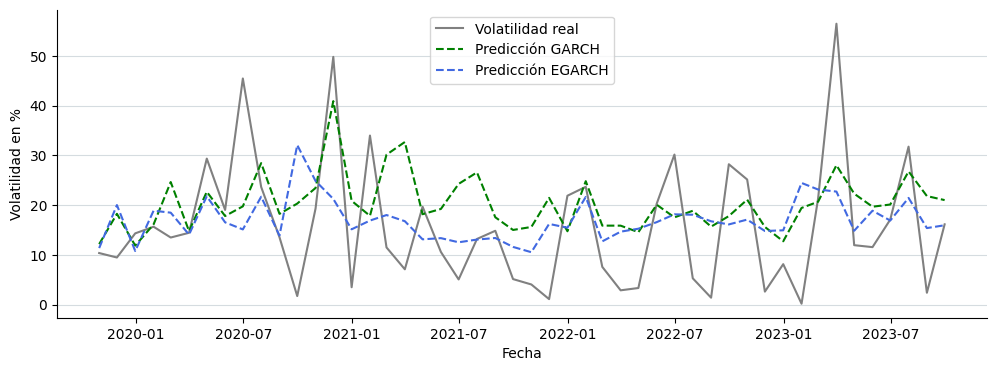

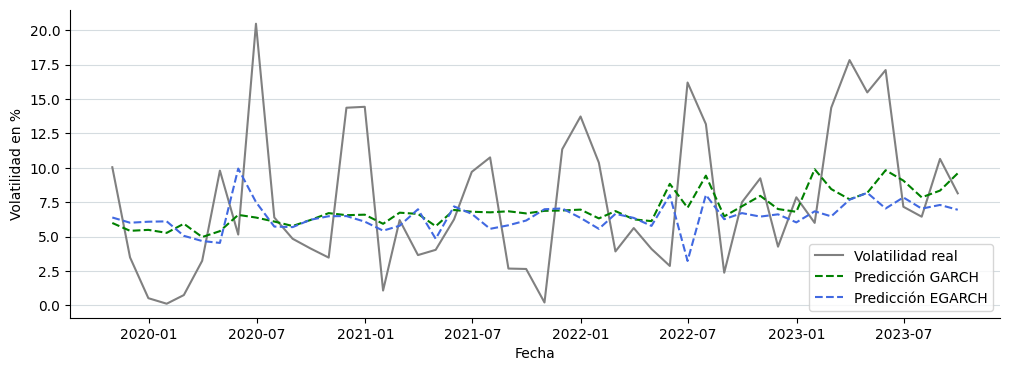

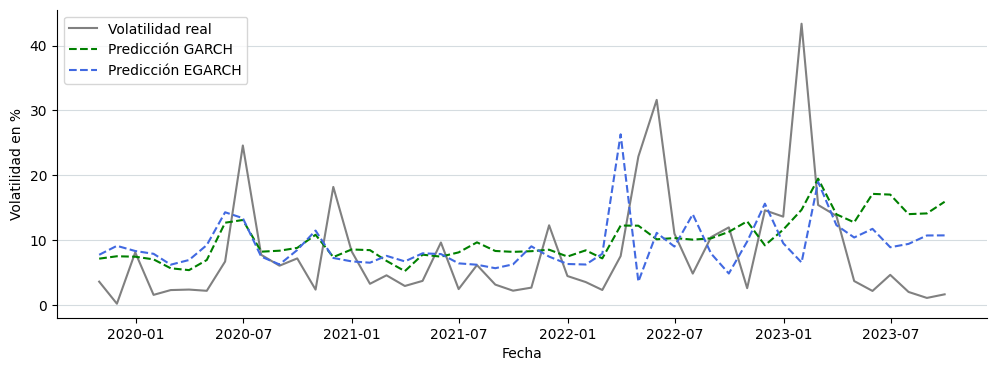

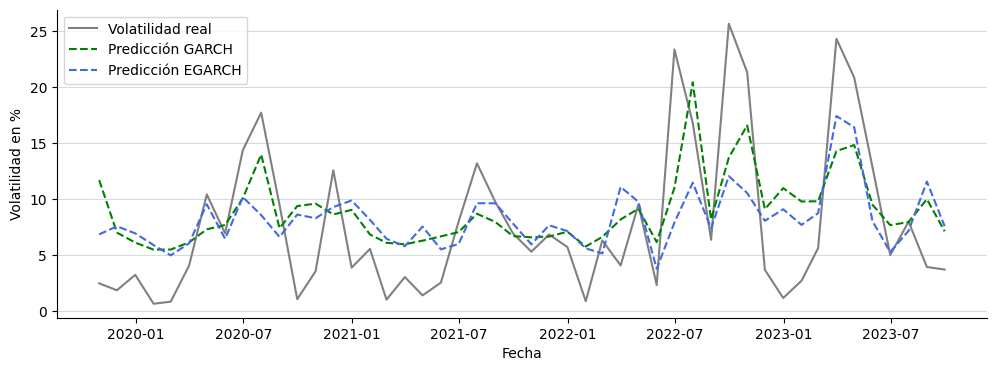

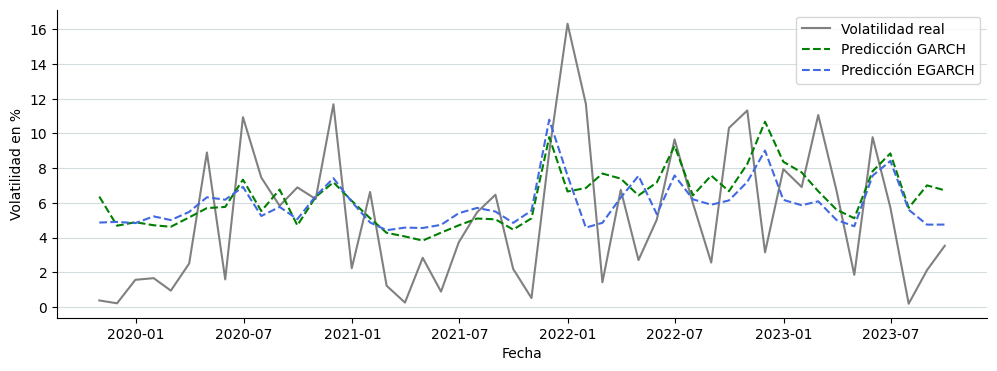

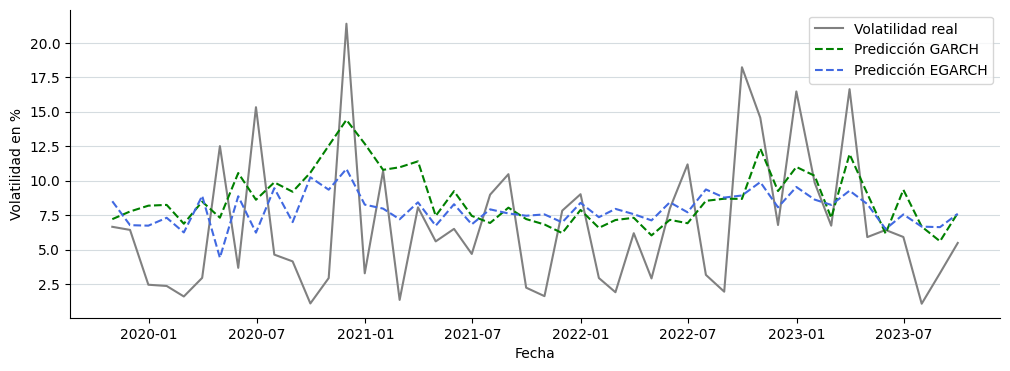

In [ ]:
rent = pd.DataFrame()
for emp in empresas:
  ticker = emp
  data = yf.download(ticker, start="2012-05-18", end="2023-09-30")
  data['R_Log'] = 100*data['Close'].apply(np.log).diff().dropna()
  rent= data['R_Log'].resample(td).sum()
  rentabilidad = rent.replace(0.000000, np.nan).dropna()
  vol = rentabilidad.rolling(window=2).std().dropna()
  best_aic = np.inf
  P, Q = [1,2,3,4], [1,2,3,4]
  for p in P:  # Rango de valores para el componente autoregresivo (p)
    for q in Q:  # Rango de valores para el componente de media móvil (q)
           model = arch_model(rentabilidad, vol='GARCH', p=p, q=q)
           results = model.fit(disp='off')
           aic = results.aic
           if aic < best_aic:
              best_aic = aic
              best_order = (p, q)
  print(f'Mejor orden (p, q) según AIC para {emp}:', best_order)
  # BUCLE DE PREDICCIÓN
  rolling_predictions = []
  # Bucle de predicción
  for i in range(0,test_size,N):
      train = rentabilidad[i:-(test_size-i)] # Datos de entrenamiento usando ventana móvil ¿Rentabilidad o Volatilidad como entrada?
      # Definimos y entrenamos el modelo
      model = arch_model(train, p=p, q=q, mean = 'constant', vol = 'GARCH', dist = 'normal')
      model_fit = model.fit(disp='off')
      # Predecimos los N siguientes valores
      pred = model_fit.forecast(horizon=N)
      # Calculamos la volatilidad aplicando sqrt a la media de la varianza de los valores predecidos
      rolling_predictions.extend(np.sqrt(pred.variance.values[-1,:]))
  # Transformamos el vector de la volatilidad predicha en una serie con el mismo indice que los retornos diarios
  rolling_predictions = pd.Series(rolling_predictions, index=vol.index[-test_size:])
  rolling_predictions = rolling_predictions.dropna() # Nos aseguramos que los índices coincidan
  print(rolling_predictions[2:].shape)
  # BUCLE DE ESTIMACIÓN DE LOS PARÁMETROS P Y Q
  # BUCLE DE ESTIMACIÓN DE LOS PARÁMETROS P Y Q
  P, Q = [1,2,3], [0] # D -> P, Q = [1,2,3,4], [1,2,3,4]  W -> P, Q = [1,2,3,4], [1,2,3]  M -> P, Q = [1,2,3], [0]
  for p in P:  # Rango de valores para el componente autoregresivo (p)
    for q in Q:  # Rango de valores para el componente de media móvil (q)
           model = arch_model(rentabilidad, vol='EGARCH', p=p, q=q, o=0)
           results = model.fit(disp='off', options={'maxiter': 1000})
           aic = results.aic
           if aic < best_aic:
              best_aic = aic
              best_order = (p, q)
  print(f'Mejor orden (p, q) según AIC para {emp}:', best_order)
  # BUCLE DE PREDICCIÓN
  rolling_predictions_E = []
  # Bucle de predicción
  for i in range(0,test_size,N):
      train = rentabilidad[i:-(test_size-i)] # Datos de entrenamiento usando ventana móvil ¿Rentabilidad o Volatilidad como entrada?
      # Definimos y entrenamos el modelo
      model = arch_model(train, p=p, q=q, o=0, vol = 'EGARCH')
      model_fit = model.fit(disp='off', options={'maxiter': 1000})
      # Predecimos los N siguientes valores
      pred = model_fit.forecast(horizon=N)
      # Calculamos la volatilidad aplicando sqrt a la media de la varianza de los valores predecidos
      rolling_predictions_E.extend(np.sqrt(pred.variance.values[-1,:]))
  # Transformamos el vector de la volatilidad predicha en una serie con el mismo indice que los retornos diarios
  rolling_predictions_E = pd.Series(rolling_predictions_E, index=vol.index[-test_size:])
  rolling_predictions_E = rolling_predictions_E.dropna() # Nos aseguramos que los índices coincidan
  print(rolling_predictions_E[2:].shape)
  # CALCULO RMSE y MAPE
  vol_moved = vol[-test_size-1:].shift(2).dropna() # N=1 --> 2
  mse = mean_squared_error(rolling_predictions[2:], vol_moved[1:])
  rmse = np.sqrt(mse)
  mape = mean_absolute_percentage_error(rolling_predictions[2:], vol_moved[1:])
  print(tabulate([[ticker,mse,rmse,mape]],
                headers = ['MSE', 'RMSE', 'MAPE'],
                tablefmt = 'fancy_grid',stralign='center',numalign='center',floatfmt=".4f"))
  mse = mean_squared_error(rolling_predictions_E[2:], vol_moved[1:])
  rmse = np.sqrt(mse)
  mape = mean_absolute_percentage_error(rolling_predictions_E[2:], vol_moved[1:])
  print(tabulate([[ticker,mse,rmse,mape]],
                headers = ['MSE', 'RMSE', 'MAPE'],
                tablefmt = 'fancy_grid',stralign='center',numalign='center',floatfmt=".4f"))
  # GRÁFICO PRED vs REAL
  color_real = 'grey'  # Azul oscuro o verde oscuro
  color_garch = 'green'  # Rojo o naranja
  color_egarch = 'royalblue'  # Rojo o naranja
  fig,ax = plt.subplots(figsize=(12,4))
  ax.grid(which="major", axis='y', color='#758D99', alpha=0.3, zorder=1)
  ax.spines[['top', 'right']].set_visible(False)
  plt.plot(vol_moved[1:].index, vol_moved[1:], color=color_real, label='Volatilidad Real')
  plt.plot(rolling_predictions[2:], color=color_garch, linestyle='--')
  plt.plot(rolling_predictions_E[2:], color=color_egarch, linestyle='--')
  #plt.title(f'Predicción de la volatilidad {dtime} de {ticker}')
  plt.legend(['Volatilidad real','Predicción GARCH','Predicción EGARCH'])
  plt.xlabel('Fecha')
  plt.ylabel('Volatilidad en %')

2018-6-30 -- 3.68  1.16
2013-6-30 -- 3.72  1.19